In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin
import seaborn as sns
# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'

In [3]:
# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        # print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print()
            # print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))

    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    # diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula

    '''Solar Zenith Angle'''
    NOAA_Zenith_1 = NOAA[0][7] 
    NOAA_Zenith_2 = NOAA[1][7]
    NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDT_Zenith = NZDT_Zenith.astype(float)
    #remove nan values from NZDTup_ir 
    NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time, NZDT_Zenith

In [4]:
# import panel data function
def Import_Panel_Data(year, day):
    input_1 = year
    input_2 = day
    # --------REAL PANEL DATA-------------
    #Read the CSV files based on user input
    file_101 = pd.read_csv(f"{InputPath}/spo_dev101_{input_1}_{input_2}.csv",delimiter=',')
    # file_103 = pd.read_csv(f"{InputPath}/spo_dev103_{input_1}_{input_2}.csv",delimiter=',')
    
    # Rename the Device ID column to voltage and Voltage to Current
    file_101.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True)
    # file_103.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True) # There is a mismatch in the file so voltage column contains current and Device ID contains voltage
    
    # Each file has the data for more than just the day it is. We want to remove these extra dataS
    
    def date2num(date_str): # Renamed 'date' to 'date_str' to avoid confusion with the datetime.date object
        # 26 # first conver the xxxx-xx-xx format to date(xxxx, xx, xx)
    
        # You can skip splitting the string and go directly to parsing:
        date_object = datetime.strptime(date_str, '%Y-%m-%d').date()
        
        # 29 # return the day of the year (%j) as an integer
        # The strftime method returns a string, so we convert it to an integer.
        return int(date_object.strftime('%j'))
    # print(f'DEBUG: {input_2}')
    date = file_101['Date']
    NumberDate = date.apply(date2num)
    mask_to_keep =  NumberDate <= int(input_2)
    file_101 = file_101[mask_to_keep]
    # print(f'DEBUG: {mask_to_keep}')
    # print(f'DEBUG: {NumberDate}')
    
    # date = file_103['Date']
    # NumberDate = date.apply(date2num)
    # mask_to_keep = NumberDate <= int(input_2)
    # file_103 = file_103[mask_to_keep]
    
    #Extract time, voltage and current data
    
    time_101 = file_101['Time']
    voltage_101 = file_101['V'] 
    current_101 = file_101['A'] 
    
    # time_103 = file_103['Time']
    # voltage_103 = file_103['V'] 
    # current_103 = file_103['A'] 
    
    power_101 = voltage_101 * current_101
    # power_103 = voltage_103 * current_103
    # -----------------------------

    # print(f'len(power_101) = {len(power_101)}')
    # return power_101, power_103, time_101, time_103
    return power_101, time_101, 
    

In [5]:
# year = 25
# day  = 346


Conversion_Factor_Tuples = []
Power_Data = []
Irradiance_Data = []
Zenith_Angles = []
for year in [25,26]:

    Day_Range2025 = np.arange(334, 366, 1)
    Day_Range2026 = [f"{i:03d}" for i in range(1, 27)]
    if year == 25:
        Day_Range = Day_Range2025
    if year == 26:
        Day_Range = Day_Range2026
    for day in Day_Range:
        print()
        print()
        print(day)
        try:
            power_101_og, __, = Import_Panel_Data(year, day)
            # not using 103 but just in case:
            # power_103 = power_103_og
            # get the time_101 from day 345 because it is complete
            __,time_101 = Import_Panel_Data(25,365)
            # print(len(time_101))
            
            
            power_101_og = power_101_og.to_numpy()
            # print(f'og: {len(power_101_og)}')
            # print(len(power_101))
            # if power_101 is too small, we pad with nan
            # if len(power_101_og) <= 2880:
            #     difference = 2880 - len(power_101_og)
            #     power_101 = power_101_og
            #     for i in np.arange(0,difference,1):
            #         power_101 = np.append(power_101, np.nan)
            if len(power_101_og) <= 2880:
                difference = 2880 - len(power_101_og)
                power_101 = power_101_og
                for i in np.arange(0,difference,1):
                    power_101 = np.pad(power_101, (1, 0), constant_values=np.nan)
                    
                    
            # print(len(power_101))
            print('Power Data Success')
            Power_Data.append(power_101)
            
        except:
            Power_Data.append(np.full(2880,np.nan))
            print('Power Data Fail')

            
            # 2 component fit + 1 sharpness
            
            # Make a model for power data using irradiance
            
            # use sigmoids for smooth transition from front to back of panel
        try:
            Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, NOAA_time, Zenith = Import_NOAA_Data(year,day)
        
            def sigmoid(x, sharpness, shift):
                return np.array(1 / (1 + np.exp(-(1/sharpness)*(x + shift))))
             
            
            def model(time, Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, effs, sharpness, zenith):
                eff_direct = effs[0]
                eff_isotropic = effs[1]
                efficiency_back = .7
            
                Change_Time_1 = 280
                Change_Time_2 = Change_Time_1 + 1440/2
                Angular_Dependance_Front = np.array(np.cos(np.pi/(Change_Time_2 - Change_Time_1)*(time - (Change_Time_1 + Change_Time_2)/2))*np.cos((90-zenith)*np.pi/180))
                Angular_Dependance_Back = np.array(-Angular_Dependance_Front)
            
                # create front of panel simulation (I did tricky math to get these)
                # Directional components:
                Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, -Change_Time_1)*sigmoid(-time, sharpness, Change_Time_2)
                Back  = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, -Change_Time_2)*sigmoid(-time, sharpness, 2*Change_Time_2 - Change_Time_1)
                Secondary_Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, Change_Time_1 - 2*Change_Time_2)*sigmoid(-time, sharpness, 3*Change_Time_2 - Change_Time_1)
                Secondary_Back = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, Change_Time_2 - 2*Change_Time_1)*sigmoid(-time, sharpness, Change_Time_1)
                Total_Directional_Irradiance = Front + Back + Secondary_Front + Secondary_Back
            
                
                # add directional to the isotropic components:
                Total_Irradiance = Total_Directional_Irradiance + eff_isotropic*Diffuse_Irradiance + eff_isotropic*Upwelling_Irradiance
            
                # Multiply by area to get total power
                Total_Power = Total_Irradiance*Area
            
                # constraint of device resistor:
            
                Max_Power = 420
                Total_Power = np.clip(Total_Power, 0, Max_Power)
                return Total_Power
            
            # we want to fit the efficiencies and the sharpness
            Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, NOAA_time, Zenith = Import_NOAA_Data(year,day)
            def Fit_Model(time, eff_dir, eff_isotropic, sharpness):
                '''
                wrapping function for model
                '''
                effs = [eff_dir, eff_isotropic]
                sim_power = model(np.linspace(0,1440,1440), np.array(Direct_Irradiance), np.array(Diffuse_Irradiance), np.array(Upwelling_Irradiance), effs, 50, Zenith)
                sim_power_2880 = np.repeat(sim_power, 2)
                if len(sim_power_2880) > len(power_101_og):
                    sim_power_data_length = sim_power_2880[:len(power_101_og)]
                    # print(f'len(sim_power_data_length) = {len(sim_power_data_length)}')
                    nanmask = ~np.isnan(power_101_og)
                    # print(f'len(sim_power_data_length[nanmask]) = {len(sim_power_data_length[nanmask])}')
                    sim_power_2880 = sim_power_data_length[nanmask]
                return sim_power_2880
            
            
            # print(len(power_101))
            # Using lmfit to fit
            from lmfit import Model
            from lmfit import fit_report
            mod = Model(Fit_Model)
            
            params = mod.make_params([.22,.01, 50]) # using the diff and upwelling from edges
            # print(mod.param_names,mod.independent_vars)
            
            params['eff_dir'].set(min=0, max=1)     
            params['eff_isotropic'].set(min=0, max=1)
            params['sharpness'].set(value = 50, min = .1, max = 100)
            
            nanmask = ~np.isnan(power_101_og)
            
            DayArrayPowerLength = len(power_101_og[nanmask])
            x = np.arange(0,DayArrayPowerLength,1)
            
            # remove the nan values from power_101
            y = power_101_og[nanmask]
            
            # print(f'len(x) = {len(x)}')
            # print(f'len(y) = {len(y)}')
            
            
            result = mod.fit(y, params, time=x, method='nelder', nan_policy = 'omit')
            
            # Print a comprehensive report of the results
            # print(result.fit_report())
            
            # Access the best-fit values
            # print(f"Best Amplitude: {result.params['eff_dir'].value}")
            
            
            fitted_dir_eff = result.params['eff_dir'].value
            fitted_isotropic_eff = result.params['eff_isotropic'].value
            fitted_sharpness = result.params['sharpness'].value
            
            
            # print()
            # print()
            # print(f'fitted_dir_eff = {fitted_dir_eff}')
            # print(f'fitted_isotropic_eff = {fitted_isotropic_eff}')
            # print(f'fitted_sharpness = {fitted_sharpness}')
            
            # print(fit_report(result))
            Conversion_Factor_Tuples.append((fitted_dir_eff, fitted_isotropic_eff))
            Irradiance_Data.append((Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance))
            Zenith_Angles.append(Zenith)
            print('NOAA Data Success')
        except:
            Irradiance_Data.append((np.full(1440,np.nan),np.full(1440,np.nan),np.full(1440,np.nan)))
            Conversion_Factor_Tuples.append((np.nan, np.nan))
            Zenith_Angles.append(np.nan)
            print('NOAA Data Fail')
            







334
Power Data Success
 - Adding parameter "eff_dir"
 - Adding parameter "eff_isotropic"
 - Adding parameter "sharpness"
NOAA Data Success


335
Power Data Fail
 - Adding parameter "eff_dir"
 - Adding parameter "eff_isotropic"
 - Adding parameter "sharpness"
NOAA Data Success


336
Power Data Fail
 - Adding parameter "eff_dir"
 - Adding parameter "eff_isotropic"
 - Adding parameter "sharpness"
NOAA Data Success


337
Power Data Success
 - Adding parameter "eff_dir"
 - Adding parameter "eff_isotropic"
 - Adding parameter "sharpness"
NOAA Data Success


338
Power Data Success
 - Adding parameter "eff_dir"
 - Adding parameter "eff_isotropic"
 - Adding parameter "sharpness"
NOAA Data Success


339
Power Data Success
 - Adding parameter "eff_dir"
 - Adding parameter "eff_isotropic"
 - Adding parameter "sharpness"
NOAA Data Success


340
Power Data Success
 - Adding parameter "eff_dir"
 - Adding parameter "eff_isotropic"
 - Adding parameter "sharpness"
NOAA Data Fail


341
Power Data Succe

0       00:00:30
1       00:01:00
2       00:01:30
3       00:02:00
4       00:02:30
          ...   
2875    23:58:00
2876    23:58:30
2877    23:59:00
2878    23:59:30
2879    23:59:30
Name: Time, Length: 2880, dtype: str


/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_5062/3956077963.py:72: RuntimeWarning: Mean of empty slice
  mean_simulation_101 = np.nanmean(simulation_101)
/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_5062/3956077963.py:76: RuntimeWarning: Mean of empty slice
  mean_power_output_101 = np.nanmean(power_output_101)
/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_5062/3956077963.py:72: RuntimeWarning: Mean of empty slice
  mean_simulation_101 = np.nanmean(simulation_101)
/var/folders/zk/p32hf16n3rnbx31r3xbsvc4m0000gn/T/ipykernel_5062/3956077963.py:76: RuntimeWarning: Mean of empty slice
  mean_power_output_101 = np.nanmean(power_output_101)


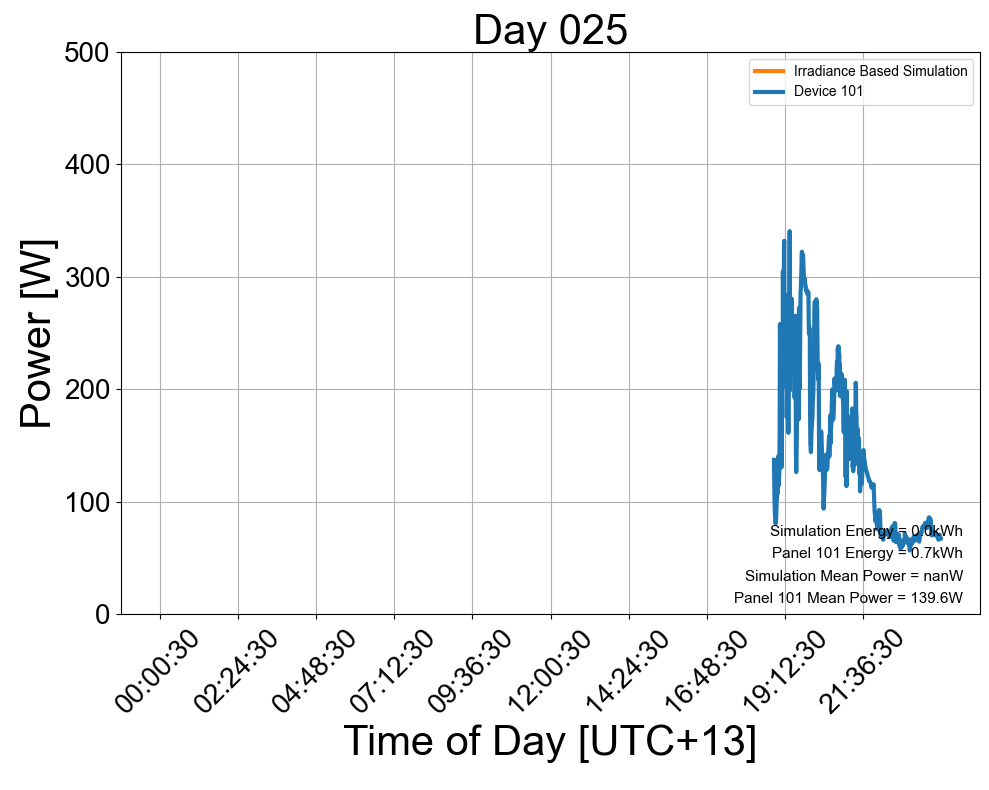

In [6]:
import matplotlib.animation as animation

starting_day = 345
# day 334 is the first day we have data for so
starting_index = starting_day - 334

fig, ax = plt.subplots(figsize = (10,8))

# simulation_101_0 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, 0),2)
x = time_101
sharpness = 50
eff_direct = Conversion_Factor_Tuples[starting_index][0]
eff_isotropic = Conversion_Factor_Tuples[starting_index][1]

Direct_Irradiance = Irradiance_Data[starting_index][0]
Diffuse_Irradiance = Irradiance_Data[starting_index][1]
Upwelling_Irradiance = Irradiance_Data[starting_index][2]
zenith = Zenith_Angles[0]

line2, = ax.plot(x, np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, zenith), 2), label = 'Irradiance Based Simulation', color = 'tab:orange',linewidth = 3)
line, = ax.plot(x, Power_Data[starting_index], label = 'Device 101', color = 'tab:blue',linewidth = 3)
# ax.set_xticks(np.linspace(0, len(time_101), 10))
ax.set_xticks(time_101[:-1:288])
print(time_101)
ax.set_title(f'Day {day}')
ax.tick_params(axis='x', labelrotation=45, labelsize = 20)
ax.tick_params(axis='y', labelsize = 20)

ax.set_ylim(0, 500)
ax.set_xlabel('Time of Day [UTC+13]', fontsize = 30)
ax.set_ylabel('Power [W]', fontsize = 30)
ax.legend()
ax.grid('on')
Combined_Day_Range = np.concatenate([Day_Range2025, Day_Range2026])

# Make text objects
text_integrated_sim = ax.text(2800+160, 410-340, f'', fontsize = 11, ha = 'right')
text_integrated_power_output = ax.text(2800+160, 410-20-340, f'', fontsize = 11, ha = 'right')
text_mean_sim = ax.text(2800+160, 410-20*2-340, f'', fontsize = 11, ha = 'right')
text_mean_power_output = ax.text(2800+160, 410-20*3-340, f'', fontsize = 11, ha = 'right')
mean_power_101 = np.zeros(len(Combined_Day_Range))
mean_power_simulation = np.zeros(len(Combined_Day_Range))
energy_101 = np.zeros(len(Combined_Day_Range))
energy_simulation = np.zeros(len(Combined_Day_Range))
def animate(i):


    eff_direct = Conversion_Factor_Tuples[i+starting_index][0]
    eff_isotropic = Conversion_Factor_Tuples[i+starting_index][1]

    Direct_Irradiance = Irradiance_Data[i+starting_index][0]
    Diffuse_Irradiance = Irradiance_Data[i+starting_index][1]
    Upwelling_Irradiance = Irradiance_Data[i+starting_index][2]
    zenith = Zenith_Angles[i+starting_index]
    
    simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, zenith),2)
    power_output_101 = Power_Data[i+starting_index]
    line2.set_ydata(simulation_101)
    line.set_ydata(power_output_101)
    ax.set_title(f'Day {Combined_Day_Range[i+starting_index]}', fontsize = 30)

    integrated_simulation_101 = trapezoid(np.nan_to_num(simulation_101,nan = 0),dx=30)
    integrated_simulation_101_kWh = integrated_simulation_101/(1000*60**2)
    text_integrated_sim.set_text(f'Simulation Energy = {np.round(integrated_simulation_101_kWh,1)}kWh')
    energy_simulation[i] = integrated_simulation_101_kWh
    
    integrated_power_output_101 = trapezoid(np.nan_to_num(power_output_101,nan = 0),dx=30)
    integrated_power_output_101_kWh = integrated_power_output_101/(1000*60**2)
    text_integrated_power_output.set_text(f'Panel 101 Energy = {np.round(integrated_power_output_101_kWh,1)}kWh')
    energy_101[i] = integrated_power_output_101_kWh
    
    mean_simulation_101 = np.nanmean(simulation_101)
    text_mean_sim.set_text(f'Simulation Mean Power = {np.round(mean_simulation_101,1)}W')
    mean_power_simulation[i] = mean_simulation_101

    mean_power_output_101 = np.nanmean(power_output_101)
    text_mean_power_output.set_text(f'Panel 101 Mean Power = {np.round(mean_power_output_101,1)}W')
    mean_power_101[i] = mean_power_output_101
    
    return line, line2, text_integrated_sim, text_integrated_power_output, text_mean_sim, text_mean_power_output


ani = animation.FuncAnimation(
    fig, animate, interval=200, blit=True, frames = len(Power_Data) -1 - starting_index)



plt.tight_layout()
# fig.subplots_adjust(bottom=0.2, right=0.92, left=0.1, top=0.9)
sns.set_theme(style = 'darkgrid')

ani.save("Models.mp4")

writer = animation.PillowWriter(fps=1,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save('Models.gif', writer=writer)

# print(Irradiance)

47
47


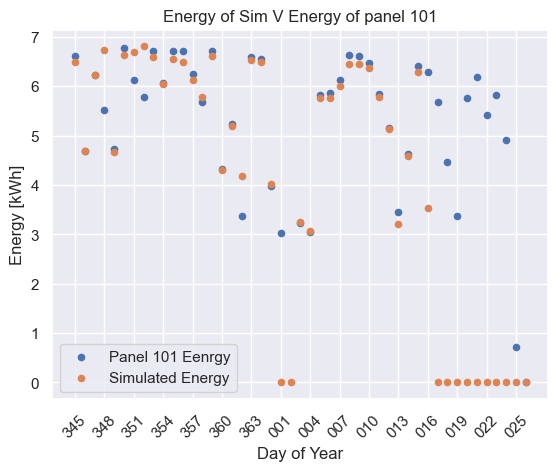

In [7]:
# Lets Compaire the energy generated for the data and model for each day
# print(mean_power_101)
# print(mean_power_simulation)
# print(energy_101)
# print(energy_simulation)


number_of_days = len(Power_Data) -1 - starting_index

Day_Range2026 = [f"{i:03d}" for i in range(1, 27)]
Day_Range2025 = [f"{i:03d}" for i in range(345, 366)]
Day_Range = np.concatenate([Day_Range2025,Day_Range2026])

energy_101_starting_day = energy_101[:number_of_days+1]
energy_simulation_starting_day = energy_simulation[:number_of_days+1]
mean_power_101_starting_day = mean_power_101[:number_of_days+1]
mean_power_simulation_starting_day = mean_power_simulation[:number_of_days+1]


print(len(Day_Range))
print(len(energy_101_starting_day))

fig, ax = plt.subplots()
ax.scatter(Day_Range, energy_101_starting_day, label = 'Panel 101 Eenrgy', s = 20)
ax.scatter(Day_Range, energy_simulation_starting_day, label = 'Simulated Energy', s = 20)

# ax2 = ax.twinx()
# ax2.scatter(Day_Range, mean_power_101_starting_day, label = 'Panel 101 Mean Power', s = 20, color = 'teal')
# ax2.scatter(Day_Range, mean_power_simulation_starting_day, label = 'Panel simulation Mean Power', s = 20, color = 'sienna') 
# ax2.set_ylabel('Power [W]')

ax.set_xticks(Day_Range[:-1:3])
ax.set_xticklabels(Day_Range[:-1:3], rotation = 45)
ax.set_xlabel('Day of Year')
ax.set_ylabel('Energy [kWh]')
ax.legend()
ax.set_title('Energy of Sim V Energy of panel 101')
plt.show()

['345' '346' '347' '348' '349' '350' '351' '352' '353' '354' '355' '356'
 '357' '358' '359' '360' '361' '362' '363' '364' '365' '001' '002' '003'
 '004' '005' '006' '007' '008' '009' '010' '011' '012' '013' '014' '015'
 '016' '017' '018' '019' '020' '021' '022' '023' '024' '025' '026']
[0.24699832280882955, 0.23527298601565377, 0.23098166899908057, 0.1011381830231492, 0.22758661900963917, 0.24615177424177737, 0.18603246784925065, 0.23043984321129501, 0.2553732801294176, 0.2112769042393749, 0.2518616418812232, 0.25544202188548415, 0.2971823664757709, 0.19607208060162695, 0.2640693791188269, 0.22890331234133815, 0.3137259565578458, 0.12202828001333715, 0.24134324293446835, 0.2401403831225134, 0.22867662798345562, nan, nan, 0.28818503435674725, 0.29787879017338154, 0.29020506509820887, 0.2442563821046953, 0.23670227146462808, 0.255838866662126, 0.2516913968209565, 0.2487806573329931, 0.20094015074108418, 0.2578818406766358, 0.23616807092909642, 0.22554523856735986, 0.2509377301117882, 0.2

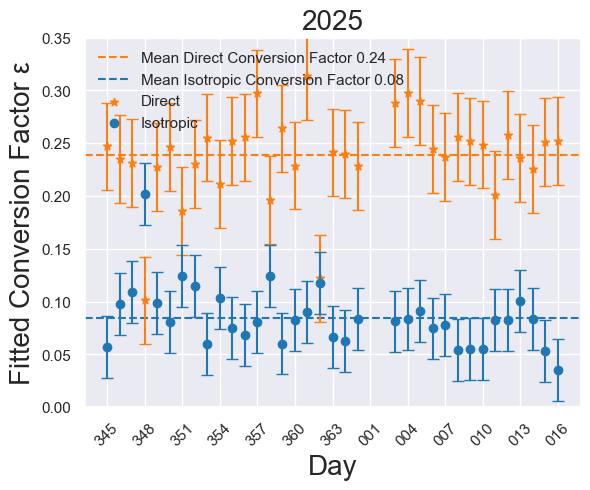

In [8]:
Direct_Conversion_Factors_0, Isotropic_Conversion_Factors_0 = zip(*Conversion_Factor_Tuples)
# # taking out the first 11 buceause bad data
Direct_Conversion_Factors = list(Direct_Conversion_Factors_0)[11:]
Isotropic_Conversion_Factors = list(Isotropic_Conversion_Factors_0)[11:]
# Day_Range2025 = [int(i) for i in Day_Range2025]

Day_Range2026 = [f"{i:03d}" for i in range(1, 27)]
Day_Range2025 = [f"{i:03d}" for i in range(345, 366)]
# Day_Range2026 = list(range(1,27))
# Day_Range2025 = list(range(345, 366))
Day_Range = np.concatenate([Day_Range2025,Day_Range2026])
print(Day_Range)
print(Direct_Conversion_Factors)

# remove the last 10 data from both
Day_Range_Truncated = Day_Range[:-9]
Direct_Conversion_Factors_Truncated = Direct_Conversion_Factors[:-9]
Isotropic_Conversion_Factors_Truncated = Isotropic_Conversion_Factors[:-9]
print()
print(Day_Range_Truncated)
print(Direct_Conversion_Factors_Truncated)
print()
print(len(Day_Range_Truncated))
print(len(Direct_Conversion_Factors_Truncated))
plt.axhline(y=np.nanmean(Direct_Conversion_Factors_Truncated), color='tab:orange', linestyle='--', label = f'Mean Direct Conversion Factor {np.round(np.nanmean(Direct_Conversion_Factors_Truncated),2)}')
plt.axhline(y=np.nanmean(Isotropic_Conversion_Factors_Truncated), color='tab:blue', linestyle='--', label = f'Mean Isotropic Conversion Factor {np.round(np.nanmean(Isotropic_Conversion_Factors_Truncated),2)}')

plt.scatter(Day_Range_Truncated, Direct_Conversion_Factors_Truncated, label = 'Direct', color = 'tab:orange', marker = '*')
plt.scatter(Day_Range_Truncated, Isotropic_Conversion_Factors_Truncated, label = 'Isotropic', color = 'tab:blue')
plt.errorbar(Day_Range_Truncated, Direct_Conversion_Factors_Truncated, yerr = np.nanstd(Direct_Conversion_Factors_Truncated), capsize = 4, linestyle = 'none', color = 'tab:orange')
plt.errorbar(Day_Range_Truncated, Isotropic_Conversion_Factors_Truncated, yerr = np.nanstd(Isotropic_Conversion_Factors_Truncated), capsize = 4, linestyle = 'none', color = 'tab:blue')
plt.xticks(Day_Range_Truncated[::3], rotation = 45)
plt.legend(framealpha = 0,loc = "upper left")
plt.title(2025, fontsize = 20)
plt.xlabel('Day', fontsize = 20)
plt.ylabel('Fitted Conversion Factor ε', fontsize = 20)
plt.grid('on')
plt.ylim(0,.35)
plt.show()

['345' '346' '347' '348' '349' '350' '351' '352' '353' '354' '355' '356'
 '357' '358' '359' '360' '361' '362' '363' '364' '365' '001' '002' '003'
 '004' '005' '006' '007' '008' '009' '010' '011' '012' '013' '014' '015'
 '016' '017' '018' '019' '020' '021' '022' '023' '024' '025' '026']
[0.24699832280882955, 0.23527298601565377, 0.23098166899908057, 0.1011381830231492, 0.22758661900963917, 0.24615177424177737, 0.18603246784925065, 0.23043984321129501, 0.2553732801294176, 0.2112769042393749, 0.2518616418812232, 0.25544202188548415, 0.2971823664757709, 0.19607208060162695, 0.2640693791188269, 0.22890331234133815, 0.3137259565578458, 0.12202828001333715, 0.24134324293446835, 0.2401403831225134, 0.22867662798345562, nan, nan, 0.28818503435674725, 0.29787879017338154, 0.29020506509820887, 0.2442563821046953, 0.23670227146462808, 0.255838866662126, 0.2516913968209565, 0.2487806573329931, 0.20094015074108418, 0.2578818406766358, 0.23616807092909642, 0.22554523856735986, 0.2509377301117882, 0.2

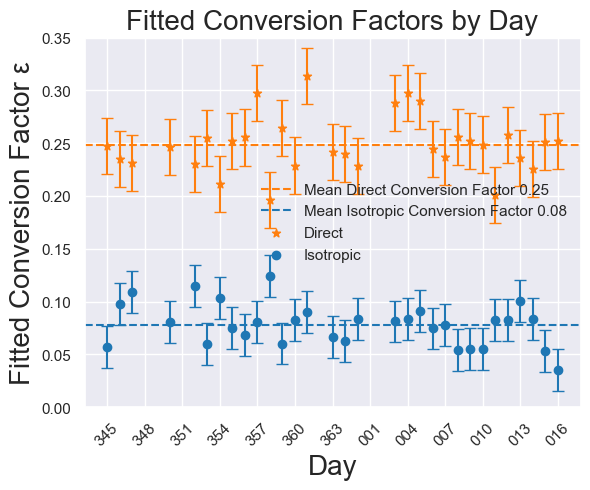

0.24873439753540685
0.07829662941734741
[0.24699832280882955, 0.23527298601565377, 0.23098166899908057, 0.1011381830231492, 0.22758661900963917, 0.24615177424177737, 0.18603246784925065, 0.23043984321129501, 0.2553732801294176, 0.2112769042393749, 0.2518616418812232, 0.25544202188548415, 0.2971823664757709, 0.19607208060162695, 0.2640693791188269, 0.22890331234133815, 0.3137259565578458, 0.12202828001333715, 0.24134324293446835, 0.2401403831225134, 0.22867662798345562, nan, nan, 0.28818503435674725, 0.29787879017338154, 0.29020506509820887, 0.2442563821046953, 0.23670227146462808, 0.255838866662126, 0.2516913968209565, 0.2487806573329931, 0.20094015074108418, 0.2578818406766358, 0.23616807092909642, 0.22554523856735986, 0.2509377301117882, 0.2518430360099282, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
[0.05706853042746707, 0.09792572295225488, 0.10922062410367328, 0.2018400161329667, 0.09856729112905027, 0.08085806517764843, 0.12466850554479453, 0.11455772790789687, 0.0595631724

In [9]:
# Lets make this plot again but I am going to mask the 


Direct_Conversion_Factors_0, Isotropic_Conversion_Factors_0 = zip(*Conversion_Factor_Tuples)
# # taking out the first 11 buceause bad data
Direct_Conversion_Factors = list(Direct_Conversion_Factors_0)[11:]
Isotropic_Conversion_Factors = list(Isotropic_Conversion_Factors_0)[11:]
# Day_Range2025 = [int(i) for i in Day_Range2025]

Day_Range2026 = [f"{i:03d}" for i in range(1, 27)]
Day_Range2025 = [f"{i:03d}" for i in range(345, 366)]
Day_Range = np.concatenate([Day_Range2025,Day_Range2026])
print(Day_Range)
print(Direct_Conversion_Factors)

# remove the last 10 data from both
Day_Range_Truncated = Day_Range[:-9]
Direct_Conversion_Factors_Truncated = Direct_Conversion_Factors[:-9]
Isotropic_Conversion_Factors_Truncated = Isotropic_Conversion_Factors[:-9]
print()
print(Day_Range_Truncated)
print(Direct_Conversion_Factors_Truncated)
print()
print(len(Day_Range_Truncated))
print(len(Direct_Conversion_Factors_Truncated))




# 4 days had noticable issues with the alignment of the data:
# 348  ie  3
# 351  ie  6
# 352  ie  7
# 362  ie  17 index
Direct_Conversion_Factors_Truncated[3] = np.nan
Isotropic_Conversion_Factors_Truncated[3] = np.nan

Direct_Conversion_Factors_Truncated[4] = np.nan
Isotropic_Conversion_Factors_Truncated[4] = np.nan

Direct_Conversion_Factors_Truncated[6] = np.nan
Isotropic_Conversion_Factors_Truncated[6] = np.nan

Direct_Conversion_Factors_Truncated[17] = np.nan
Isotropic_Conversion_Factors_Truncated[17] = np.nan




plt.axhline(y=np.nanmean(Direct_Conversion_Factors_Truncated), color='tab:orange', linestyle='--', label = f'Mean Direct Conversion Factor {np.round(np.nanmean(Direct_Conversion_Factors_Truncated),2)}')
plt.axhline(y=np.nanmean(Isotropic_Conversion_Factors_Truncated), color='tab:blue', linestyle='--', label = f'Mean Isotropic Conversion Factor {np.round(np.nanmean(Isotropic_Conversion_Factors_Truncated),2)}')

plt.scatter(Day_Range_Truncated, Direct_Conversion_Factors_Truncated, label = 'Direct', color = 'tab:orange', marker = '*')
plt.scatter(Day_Range_Truncated, Isotropic_Conversion_Factors_Truncated, label = 'Isotropic', color = 'tab:blue')
plt.errorbar(Day_Range_Truncated, Direct_Conversion_Factors_Truncated, yerr = np.nanstd(Direct_Conversion_Factors_Truncated), capsize = 4, linestyle = 'none', color = 'tab:orange')
plt.errorbar(Day_Range_Truncated, Isotropic_Conversion_Factors_Truncated, yerr = np.nanstd(Isotropic_Conversion_Factors_Truncated), capsize = 4, linestyle = 'none', color = 'tab:blue')
plt.xticks(Day_Range_Truncated[::3], rotation = 45)
plt.legend(framealpha = 0)
plt.title('Fitted Conversion Factors by Day', fontsize = 20)
plt.xlabel('Day', fontsize = 20)
plt.ylabel('Fitted Conversion Factor ε', fontsize = 20)
plt.grid('on')
plt.ylim(0,.35)
plt.show()

mean_direct_conversion_factor = np.nanmean(Direct_Conversion_Factors_Truncated)
mean_isotropic_conversion_factor = np.nanmean(Isotropic_Conversion_Factors_Truncated)

print(mean_direct_conversion_factor)
print(mean_isotropic_conversion_factor)
print(Direct_Conversion_Factors)
print(Isotropic_Conversion_Factors)

TypeError: model() missing 1 required positional argument: 'zenith'

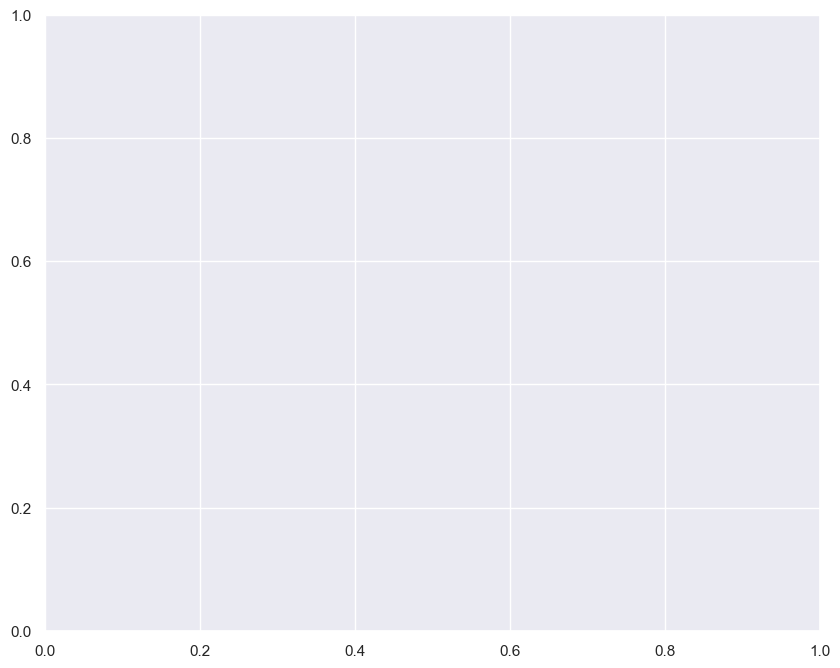

In [10]:
# using the average values of conversion factor/efficiency


import matplotlib.animation as animation

starting_day = 345
# day 334 is the first day we have data for so
starting_index = starting_day - 334

fig, ax = plt.subplots(figsize = (10,8))

# simulation_101_0 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, 0),2)
x = time_101
sharpness = 50
eff_direct = Conversion_Factor_Tuples[starting_index][0]
eff_isotropic = Conversion_Factor_Tuples[starting_index][1]

Direct_Irradiance = Irradiance_Data[starting_index][0]
Diffuse_Irradiance = Irradiance_Data[starting_index][1]
Upwelling_Irradiance = Irradiance_Data[starting_index][2]

line2, = ax.plot(x, np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness),2), label = 'Irradiance Based Simulation', color = 'tab:orange',linewidth = 3)
line, = ax.plot(x, Power_Data[starting_index], label = 'Device 101', color = 'tab:blue',linewidth = 3)
# ax.set_xticks(np.linspace(0, len(time_101), 10))
ax.set_xticks(time_101[:-1:288])
print(time_101)
ax.set_title(f'Day {day}')
ax.tick_params(axis='x', labelrotation=45, labelsize = 20)
ax.tick_params(axis='y', labelsize = 20)

ax.set_ylim(0, 500)
ax.set_xlabel('Time of Day [UTC+13]', fontsize = 30)
ax.set_ylabel('Power [W]', fontsize = 30)
ax.legend()
ax.grid('on')
Combined_Day_Range = np.concatenate([Day_Range2025, Day_Range2026])

# Make text objects
text_integrated_sim = ax.text(2800+160, 410-340, f'', fontsize = 11, ha = 'right')
text_integrated_power_output = ax.text(2800+160, 410-20-340, f'', fontsize = 11, ha = 'right')
text_mean_sim = ax.text(2800+160, 410-20*2-340, f'', fontsize = 11, ha = 'right')
text_mean_power_output = ax.text(2800+160, 410-20*3-340, f'', fontsize = 11, ha = 'right')
mean_power_101 = np.zeros(len(Combined_Day_Range))
mean_power_simulation = np.zeros(len(Combined_Day_Range))
energy_101 = np.zeros(len(Combined_Day_Range))
energy_simulation = np.zeros(len(Combined_Day_Range))
def animate(i):


    # eff_direct = Conversion_Factor_Tuples[i+starting_index][0]
    # eff_isotropic = Conversion_Factor_Tuples[i+starting_index][1]

    eff_direct = mean_direct_conversion_factor
    eff_isotropic = mean_isotropic_conversion_factor

    
    Direct_Irradiance = Irradiance_Data[i+starting_index][0]
    Diffuse_Irradiance = Irradiance_Data[i+starting_index][1]
    Upwelling_Irradiance = Irradiance_Data[i+starting_index][2]
    
    simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness),2)
    power_output_101 = Power_Data[i+starting_index]
    line2.set_ydata(simulation_101)
    line.set_ydata(power_output_101)
    ax.set_title(f'Day {Combined_Day_Range[i+starting_index]}', fontsize = 30)

    integrated_simulation_101 = trapezoid(np.nan_to_num(simulation_101,nan = 0),dx=30)
    integrated_simulation_101_kWh = integrated_simulation_101/(1000*60**2)
    text_integrated_sim.set_text(f'Simulation Energy = {np.round(integrated_simulation_101_kWh,1)}kWh')
    energy_simulation[i] = integrated_simulation_101_kWh
    
    integrated_power_output_101 = trapezoid(np.nan_to_num(power_output_101,nan = 0),dx=30)
    integrated_power_output_101_kWh = integrated_power_output_101/(1000*60**2)
    text_integrated_power_output.set_text(f'Panel 101 Energy = {np.round(integrated_power_output_101_kWh,1)}kWh')
    energy_101[i] = integrated_power_output_101_kWh
    
    mean_simulation_101 = np.nanmean(simulation_101)
    text_mean_sim.set_text(f'Simulation Mean Power = {np.round(mean_simulation_101,1)}W')
    mean_power_simulation[i] = mean_simulation_101

    mean_power_output_101 = np.nanmean(power_output_101)
    text_mean_power_output.set_text(f'Panel 101 Mean Power = {np.round(mean_power_output_101,1)}W')
    mean_power_101[i] = mean_power_output_101
    
    return line, line2, text_integrated_sim, text_integrated_power_output, text_mean_sim, text_mean_power_output


ani = animation.FuncAnimation(
    fig, animate, interval=200, blit=True, frames = len(Power_Data) -1 - starting_index)



plt.tight_layout()
# fig.subplots_adjust(bottom=0.2, right=0.92, left=0.1, top=0.9)
sns.set_theme(style = 'darkgrid')

ani.save("Models_constant_conversion_factors.mp4")

writer = animation.PillowWriter(fps=1,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save('Models_constant_conversion_factors.gif', writer=writer)

# print(Irradiance)






47
47


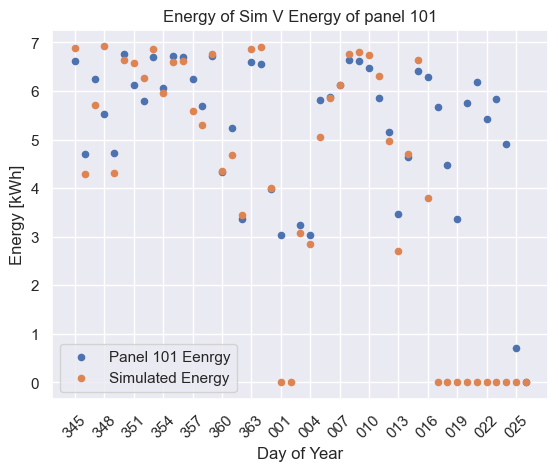

In [96]:
# Lets Compaire the energy generated for the data and model for each day
# print(mean_power_101)
# print(mean_power_simulation)
# print(energy_101)
# print(energy_simulation)


number_of_days = len(Power_Data) -1 - starting_index

Day_Range2026 = [f"{i:03d}" for i in range(1, 27)]
Day_Range2025 = [f"{i:03d}" for i in range(345, 366)]
Day_Range = np.concatenate([Day_Range2025,Day_Range2026])

energy_101_starting_day = energy_101[:number_of_days+1]
energy_simulation_starting_day = energy_simulation[:number_of_days+1]
mean_power_101_starting_day = mean_power_101[:number_of_days+1]
mean_power_simulation_starting_day = mean_power_simulation[:number_of_days+1]


print(len(Day_Range))
print(len(energy_101_starting_day))

fig, ax = plt.subplots()
ax.scatter(Day_Range, energy_101_starting_day, label = 'Panel 101 Eenrgy', s = 20)
ax.scatter(Day_Range, energy_simulation_starting_day, label = 'Simulated Energy', s = 20)

# ax2 = ax.twinx()
# ax2.scatter(Day_Range, mean_power_101_starting_day, label = 'Panel 101 Mean Power', s = 20, color = 'teal')
# ax2.scatter(Day_Range, mean_power_simulation_starting_day, label = 'Panel simulation Mean Power', s = 20, color = 'sienna') 
# ax2.set_ylabel('Power [W]')

ax.set_xticks(Day_Range[:-1:3])
ax.set_xticklabels(Day_Range[:-1:3], rotation = 45)
ax.set_xlabel('Day of Year')
ax.set_ylabel('Energy [kWh]')
ax.legend()
ax.set_title('Energy of Sim V Energy of panel 101')

plt.show()